CNN/LSTM Pipeline

**Goal:** Confirm the data pipeline is correct before AutoML.  
Two checks must both pass:

| Check | What it proves | Pass condition |
|---|---|---|
| **Overfit test** | Model can learn (architecture + data wired correctly) | Train acc ≥ 99% on 10 clips |
| **Full train** | Pipeline generalises (labels, splits, normalization correct) | Val top-1 > 35%, top-5 > 65% |

Random chance on WLASL100 = **1% top-1 / 5% top-5**

```
Input (30, 258)
  Conv1D(64, k=3) + BN + ReLU   ×3   → spatial: joint relationships per frame
  BiLSTM(256) + Dropout(0.4)    ×2   → temporal: motion across 30 frames
  Dense(512) + Dropout(0.2)          → classification head
  Dense(num_classes) + Softmax
```

## 0 · Imports

In [1]:
import os, json, random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow : {tf.__version__}')
print(f'GPUs       : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.21.0
GPUs       : []


## 1 · Config

In [2]:
PROCESSED_DIR = Path('../dataset/processed')   # output of preprocess_data.ipynb
OUT_DIR       = Path('baseline_results')
OUT_DIR.mkdir(exist_ok=True)

SEQ_LEN      = 30     # frames per clip
NUM_FEATURES = 258    # pose(132) + left_hand(63) + right_hand(63)
BATCH_SIZE   = 32
EPOCHS       = 150
LR           = 1e-3

print(f'Input shape : ({SEQ_LEN}, {NUM_FEATURES})')

Input shape : (30, 258)


## 2 · Load data + sanity checks

In [3]:
train_npz = np.load(PROCESSED_DIR / 'train.npz')
val_npz   = np.load(PROCESSED_DIR / 'val.npz')
test_npz  = np.load(PROCESSED_DIR / 'test.npz')

X_train, y_train = train_npz['X'], train_npz['y']
X_val,   y_val   = val_npz['X'],   val_npz['y']
X_test,  y_test  = test_npz['X'],  test_npz['y']

with open(PROCESSED_DIR / 'label_to_gloss.json') as f:
    label_to_gloss = {int(k): v for k, v in json.load(f).items()}

NUM_CLASSES = len(label_to_gloss)

# ── Sanity checks ─────────────────────────────────────────────────────────────
checks = [
    (X_train.shape[1] == SEQ_LEN,            f'SEQ_LEN mismatch — got {X_train.shape[1]}'),
    (X_train.shape[2] == NUM_FEATURES,       f'NUM_FEATURES mismatch — got {X_train.shape[2]}'),
    (X_train.dtype   == np.float32,          f'dtype must be float32 — got {X_train.dtype}'),
    (not np.isnan(X_train).any(),            'NaN values in X_train'),
    (not np.isinf(X_train).any(),            'Inf values in X_train'),
    (X_train.max()   <= 2.0,                 f'Max value {X_train.max():.3f} looks wrong'),
    (y_train.max()   <  NUM_CLASSES,         f'Label {y_train.max()} >= NUM_CLASSES {NUM_CLASSES}'),
    (len(np.unique(y_train)) == NUM_CLASSES, 'Some classes missing from train set'),
]

all_ok = True
for ok, msg in checks:
    print(f'  [{"✓" if ok else "✗ FAIL"}]  {msg}')
    if not ok:
        all_ok = False

print()
print(f'Train  : {X_train.shape}  ({NUM_CLASSES} classes)')
print(f'Val    : {X_val.shape}')
print(f'Test   : {X_test.shape}')
print(f'Range  : [{X_train.min():.3f}, {X_train.max():.3f}]')
print(f'Zero % : {100*(X_train==0).mean():.1f}%  ← absent landmarks, expected')

if not all_ok:
    raise RuntimeError('Sanity checks failed — fix pipeline before continuing.')
print('\nAll checks passed ✓')

  [✓]  SEQ_LEN mismatch — got 30
  [✓]  NUM_FEATURES mismatch — got 258
  [✓]  dtype must be float32 — got float32
  [✓]  NaN values in X_train
  [✓]  Inf values in X_train
  [✓]  Max value 1.000 looks wrong
  [✓]  Label 99 >= NUM_CLASSES 100
  [✓]  Some classes missing from train set

Train  : (1396, 30, 258)  (100 classes)
Val    : (320, 30, 258)
Test   : (190, 30, 258)
Range  : [-0.987, 1.000]
Zero % : 62.1%  ← absent landmarks, expected

All checks passed ✓


## 3 · Class weights

In [4]:
# WLASL100 is imbalanced — some signs have 30+ clips, others just 5.
# Balanced weights make the loss treat every class equally regardless of count.
raw_weights   = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train)
class_weights = {i: float(w) for i, w in enumerate(raw_weights)}

counts = np.bincount(y_train, minlength=NUM_CLASSES)
print(f'Clips per class — min: {counts.min()}  max: {counts.max()}  mean: {counts.mean():.1f}')
print(f'Weight range    — min: {raw_weights.min():.3f}  max: {raw_weights.max():.3f}')

Clips per class — min: 10  max: 29  mean: 14.0
Weight range    — min: 0.481  max: 1.396


## 4 · tf.data pipelines

In [5]:
@tf.function
def augment(x, y):
    """Light augmentation applied only during training."""
    # 1. Gaussian noise — only on detected landmarks (non-zero)
    noise = tf.random.normal(tf.shape(x), stddev=0.005)
    x     = x + noise * tf.cast(x != 0, tf.float32)

    # 2. Left/right mirror — swap hands and negate x-coordinates
    if tf.random.uniform(()) > 0.5:
        lh  = x[:, 132:195]
        rh  = x[:, 195:258]
        x   = tf.concat([x[:, :132], rh, lh], axis=-1)
        neg = tf.tensor_scatter_nd_update(
            tf.ones([NUM_FEATURES]),
            [[i] for i in range(132, 258, 3)],
            [-1.0] * len(range(132, 258, 3))
        )
        x = x * neg
    return x, y


def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices(
        (X.astype(np.float32), y.astype(np.int32))
    )
    if training:
        ds = ds.shuffle(len(X), seed=SEED).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val,   y_val)
test_ds  = make_ds(X_test,  y_test)

# Verify one batch
bx, by = next(iter(train_ds))
print(f'Batch X : {bx.shape}  {bx.dtype}')
print(f'Batch y : {by.shape}  {by.dtype}')

Batch X : (32, 30, 258)  <dtype: 'float32'>
Batch y : (32,)  <dtype: 'int32'>


## 5 · Build model

In [7]:
def build_model(num_classes: int) -> keras.Model:
    inp = keras.Input(shape=(SEQ_LEN, NUM_FEATURES), name='keypoints')
    x   = inp

    # ── CNN spatial encoder ───────────────────────────────────────────────────
    # Learns relationships between joints within a single frame
    # use_bias=False because BatchNormalization has its own bias term
    for i in range(3):
        x = layers.Conv1D(64, kernel_size=3, padding='same',
                          use_bias=False, name=f'conv{i}')(x)
        x = layers.BatchNormalization(name=f'bn{i}')(x)
        x = layers.ReLU(name=f'relu{i}')(x)
    # shape: (batch, 30, 64)

    # ── BiLSTM temporal encoder ───────────────────────────────────────────────
    # Learns how the sign evolves over the 30 frames
    # Layer 1: return_sequences=True → passes full sequence to layer 2
    # Layer 2: return_sequences=False → collapses to one vector per clip
    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=True), name='bilstm0'
    )(x)
    x = layers.Dropout(0.4, name='drop0')(x)

    x = layers.Bidirectional(
        layers.LSTM(256, return_sequences=False), name='bilstm1'
    )(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    # shape: (batch, 512)

    # ── Classifier head ───────────────────────────────────────────────────────
    x   = layers.Dense(512, activation='relu', name='dense')(x)
    x   = layers.Dropout(0.2, name='drop2')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return keras.Model(inp, out, name='baseline_cnn_lstm')


model = build_model(NUM_CLASSES)

model.compile(
    optimizer = keras.optimizers.Adam(LR),
    loss      = keras.losses.SparseCategoricalCrossentropy(),
    metrics   = [
        keras.metrics.SparseCategoricalAccuracy(name='acc'),
        keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top5'),
    ]
)

model.summary(line_length=72)
print(f'\nTotal params : {model.count_params():,}')
print(f'Float32 size : {model.count_params()*4/1e6:.1f} MB')

Model: "baseline_cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ keypoints (InputLayer)        │ (None, 30, 258)       │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv0 (Conv1D)                │ (None, 30, 64)        │       49,536 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bn0 (BatchNormalization)      │ (None, 30, 64)        │          256 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ relu0 (ReLU)                  │ (None, 30, 64)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv1 (Conv1D)                │ (None, 30, 64)        │       12,288 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bn1 (BatchNormalization)      │ (None, 30, 64)        │          256 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ relu1 (ReLU)                  │ (None, 30, 64)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ conv2 (Conv1D)                │ (None, 30, 64)        │       12,288 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bn2 (BatchNormalization)      │ (None, 30, 64)        │          256 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ relu2 (ReLU)                  │ (None, 30, 64)        │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bilstm0 (Bidirectional)       │ (None, 30, 512)       │      657,408 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ drop0 (Dropout)               │ (None, 30, 512)       │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bilstm1 (Bidirectional)       │ (None, 512)           │    1,574,912 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ drop1 (Dropout)               │ (None, 512)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 512)           │      262,656 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ drop2 (Dropout)               │ (None, 512)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ output (Dense)                │ (None, 100)           │       51,300 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 2,621,156 (10.00 MB)

 Trainable params: 2,620,772 (10.00 MB)

 Non-trainable params: 384 (1.50 KB)


Total params : 2,621,156
Float32 size : 10.5 MB


## 6 · CHECK 1 — Overfit test

Train on **10 clips only**, dropout disabled.  
**Must reach ≥ 99% training accuracy.** If it fails, stop and diagnose — do not proceed to full training.

Training on 10 clips (no dropout)...


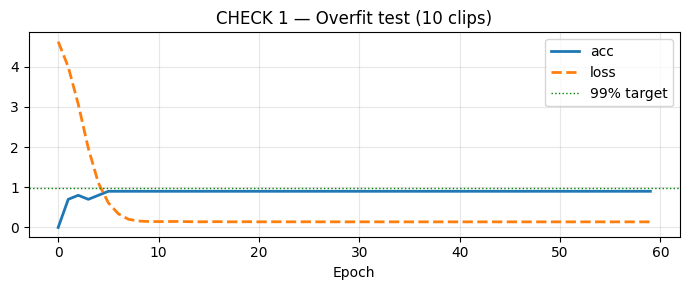

Final train acc : 0.9000
✗  CHECK 1 FAILED
   Do NOT continue. Diagnose first:
   1. Print X_tiny.shape — must be (10, 30, 258)
   2. Print y_tiny.dtype — must be int32, not float32
   3. Check np.isnan(X_tiny).any() — must be False
   4. Try learning_rate=1e-2 (might be too low for 10 samples)


In [8]:
# One clip per class, 10 classes
tiny_idx = [np.where(y_train == c)[0][0] for c in range(10)]
X_tiny   = X_train[tiny_idx]
y_tiny   = y_train[tiny_idx]

# Same architecture but dropout = 0 so it CAN overfit
inp_t = keras.Input(shape=(SEQ_LEN, NUM_FEATURES))
x_t   = inp_t
for _ in range(3):
    x_t = layers.Conv1D(64, 3, padding='same', use_bias=False)(x_t)
    x_t = layers.BatchNormalization()(x_t)
    x_t = layers.ReLU()(x_t)
x_t = layers.Bidirectional(layers.LSTM(256, return_sequences=True))(x_t)
x_t = layers.Bidirectional(layers.LSTM(256, return_sequences=False))(x_t)
x_t = layers.Dense(512, activation='relu')(x_t)
out_t = layers.Dense(NUM_CLASSES, activation='softmax')(x_t)

tiny_model = keras.Model(inp_t, out_t)
tiny_model.compile(
    optimizer = keras.optimizers.Adam(1e-3),
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['acc']
)

print('Training on 10 clips (no dropout)...')
tiny_hist = tiny_model.fit(
    X_tiny, y_tiny,
    epochs=60, batch_size=10, verbose=0
)

final_acc  = tiny_hist.history['acc'][-1]
epoch_hit  = next((i+1 for i,a in enumerate(tiny_hist.history['acc']) if a >= 0.99), None)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tiny_hist.history['acc'],  linewidth=2, label='acc')
ax.plot(tiny_hist.history['loss'], linewidth=2, linestyle='--', label='loss')
ax.axhline(0.99, color='green', linestyle=':', linewidth=1, label='99% target')
ax.set_title('CHECK 1 — Overfit test (10 clips)')
ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'overfit_test.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Final train acc : {final_acc:.4f}')
if final_acc >= 0.99:
    print(f'✓  CHECK 1 PASSED — reached 99% at epoch {epoch_hit}')
    print('   Architecture and data wiring are correct. Proceed to full training.')
else:
    print('✗  CHECK 1 FAILED')
    print('   Do NOT continue. Diagnose first:')
    print('   1. Print X_tiny.shape — must be (10, 30, 258)')
    print('   2. Print y_tiny.dtype — must be int32, not float32')
    print('   3. Check np.isnan(X_tiny).any() — must be False')
    print('   4. Try learning_rate=1e-2 (might be too low for 10 samples)')

## 7 · CHECK 2 — Full training

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_acc', patience=15, mode='max',
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-5, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath       = str(OUT_DIR / 'best.keras'),
        monitor        = 'val_acc',
        save_best_only = True,
        mode           = 'max',
        verbose        = 1,
    ),
    keras.callbacks.CSVLogger(str(OUT_DIR / 'log.csv')),
]

print('Starting full training...')
print(f'  Up to {EPOCHS} epochs  |  early stop patience=15  |  class weights ON\n')

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = EPOCHS,
    class_weight    = class_weights,
    callbacks       = callbacks,
    verbose         = 1,
)

Starting full training...
  Up to 150 epochs  |  early stop patience=15  |  class weights ON

Epoch 1/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.0078 - loss: 4.6540 - top5: 0.0335
Epoch 1: val_acc improved from None to 0.01250, saving model to baseline_results\best.keras

Epoch 1: finished saving model to baseline_results\best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - acc: 0.0079 - loss: 4.6561 - top5: 0.0365 - val_acc: 0.0125 - val_loss: 4.5791 - val_top5: 0.0750 - learning_rate: 0.0010
Epoch 2/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - acc: 0.0238 - loss: 4.5092 - top5: 0.1004
Epoch 2: val_acc improved from 0.01250 to 0.03125, saving model to baseline_results\best.keras

Epoch 2: finished saving model to baseline_results\best.keras
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - acc: 0.0236 - loss: 4.5215 - top5: 0.0960 - val_acc: 0.0312 - val_loss: 4.4871 - val_top5: 0.1063 - learning_rate: 0.0010
Epoch 3/150
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - acc: 0.0278 - loss:

## 8 · Results & verdict

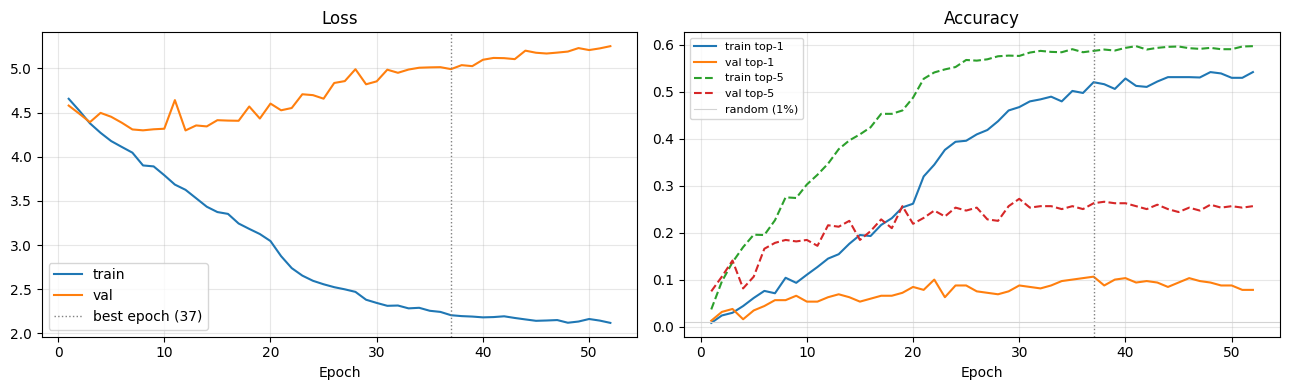

  BASELINE RESULTS
  Best epoch   : 37 / 52
  Val  top-1   : 10.6%
  Val  top-5   : 26.2%
  Test top-1   : 13.7%   (random = 1.0%)
  Test top-5   : 26.8%   (random = 5.0%)
  Improvement  : 13.7× over random
──────────────────────────────────────────────────
  Top-1 ≥ 35%  →  ✗  FAIL
  Top-5 ≥ 65%  →  ✗  FAIL

  Train/val gap : 0.414  →  Overfitting. Increase dropout or augmentation.


In [10]:
h          = history.history
best_epoch = int(np.argmax(h['val_acc'])) + 1
best_top1  = max(h['val_acc'])
best_top5  = h['val_top5'][best_epoch - 1]
epochs_ran = range(1, len(h['loss']) + 1)

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs_ran, h['loss'],     label='train', linewidth=1.5)
axes[0].plot(epochs_ran, h['val_loss'], label='val',   linewidth=1.5)
axes[0].axvline(best_epoch, color='gray', linestyle=':', linewidth=1,
                label=f'best epoch ({best_epoch})')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, h['acc'],      label='train top-1', linewidth=1.5)
axes[1].plot(epochs_ran, h['val_acc'],  label='val top-1',   linewidth=1.5)
axes[1].plot(epochs_ran, h['top5'],     label='train top-5', linewidth=1.5, linestyle='--')
axes[1].plot(epochs_ran, h['val_top5'], label='val top-5',   linewidth=1.5, linestyle='--')
axes[1].axvline(best_epoch, color='gray', linestyle=':', linewidth=1)
axes[1].axhline(0.01, color='lightgray', linewidth=0.8, label='random (1%)')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Test set ──────────────────────────────────────────────────────────────────
best_model = keras.models.load_model(OUT_DIR / 'best.keras')
test_loss, test_top1, test_top5 = best_model.evaluate(test_ds, verbose=0)

PASS_TOP1 = 0.35
PASS_TOP5 = 0.65
top1_pass = test_top1 >= PASS_TOP1
top5_pass = test_top5 >= PASS_TOP5

print('=' * 50)
print('  BASELINE RESULTS')
print('=' * 50)
print(f'  Best epoch   : {best_epoch} / {len(epochs_ran)}')
print(f'  Val  top-1   : {best_top1*100:.1f}%')
print(f'  Val  top-5   : {best_top5*100:.1f}%')
print(f'  Test top-1   : {test_top1*100:.1f}%   (random = {100/NUM_CLASSES:.1f}%)')
print(f'  Test top-5   : {test_top5*100:.1f}%   (random = {500/NUM_CLASSES:.1f}%)')
print(f'  Improvement  : {test_top1/(1/NUM_CLASSES):.1f}× over random')
print('─' * 50)
print(f'  Top-1 ≥ {PASS_TOP1*100:.0f}%  →  {"✓  PASS" if top1_pass else "✗  FAIL"}')
print(f'  Top-5 ≥ {PASS_TOP5*100:.0f}%  →  {"✓  PASS" if top5_pass else "✗  FAIL"}')
print('=' * 50)

# Gap diagnosis
train_top1_at_best = h['acc'][best_epoch - 1]
gap = train_top1_at_best - best_top1
still_rising = abs(h['val_acc'][-1] - best_top1) < 0.01

print(f'\n  Train/val gap : {gap:.3f}', end='  ')
if top1_pass and top5_pass:
    print('→  Pipeline validated ✓  Ready for AutoML.')
elif still_rising:
    print('→  Val acc still climbing at cutoff. Increase EPOCHS to 200.')
elif gap > 0.25:
    print('→  Overfitting. Increase dropout or augmentation.')
else:
    print('→  Underfitting. Check normalization or increase model size.')

## 9 · Quick error analysis

In [11]:
y_prob = best_model.predict(test_ds, verbose=0)   # (N, num_classes)
y_pred = np.argmax(y_prob, axis=1)
correct = y_pred == y_test

# Per-class accuracy — sorted worst to best
per_cls = {}
for c in range(NUM_CLASSES):
    mask = y_test == c
    if mask.sum() > 0:
        per_cls[c] = (y_pred[mask] == c).mean()
sorted_cls = sorted(per_cls.items(), key=lambda x: x[1])

print('5 worst classes:')
for c, acc in sorted_cls[:5]:
    n = (y_test == c).sum()
    print(f'  [{c:3d}] {label_to_gloss[c]:<18}  acc={acc:.2f}  n_test={n}')

print('\n5 best classes:')
for c, acc in sorted_cls[-5:]:
    n = (y_test == c).sum()
    print(f'  [{c:3d}] {label_to_gloss[c]:<18}  acc={acc:.2f}  n_test={n}')

# Confidence check — correct preds should have higher confidence
conf = y_prob.max(axis=1)
print(f'\nConfidence — correct: {conf[correct].mean():.3f}  wrong: {conf[~correct].mean():.3f}')
print('(Correct predictions should be more confident — if not, increase label_smoothing)')

5 worst classes:
  [  1] drink               acc=0.00  n_test=4
  [  2] computer            acc=0.00  n_test=4
  [  7] who                 acc=0.00  n_test=2
  [  8] candy               acc=0.00  n_test=3
  [  9] cousin              acc=0.00  n_test=3

5 best classes:
  [ 12] help                acc=1.00  n_test=2
  [ 52] apple               acc=1.00  n_test=1
  [ 54] change              acc=1.00  n_test=1
  [ 62] enjoy               acc=1.00  n_test=1
  [ 73] time                acc=1.00  n_test=1

Confidence — correct: 0.742  wrong: 0.302
(Correct predictions should be more confident — if not, increase label_smoothing)
